# Eyeglasses latent direction

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from tqdm.auto import tqdm

from dataclasses import dataclass
import pickle

import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
STYLEGAN2_DIR = PROJECT_DIR / 'stylegan2'
if str(STYLEGAN2_DIR) not in sys.path:
    sys.path.insert(0, str(STYLEGAN2_DIR))

from stylegan2 import *
from stylegan2.torch_utils.misc import get_device

from classifier import Classifier

/Users/antoningranados/Documents/School/Telecom/ima/APM_4IM06_TP/project.nosync/Latent-Space-Faces/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

MODELS_DIR = Path("models")
CLASSIFIER_PATH = MODELS_DIR / "classifier.pt"
ATTRIBUTE_NAMES = ["Eyeglasses", "Male", "Young"]
EYEGLASSES_INDEX = 0
MALE_INDEX = 1
YOUNG_INDEX = 2
SCORE_PATH = OUT_DIR / "attribute_scores.pt"

LOAD_BOUNDARIES = False   # load pre-computed boundaries from models/ instead of recomputing

device = get_device()
print(device)


mps


In [3]:
def image_to_display(img: torch.Tensor) -> np.ndarray:
    if img.min() < 0.0:
        img = (img + 1.0) / 2.0
    img = img.clamp(0.0, 1.0)
    img = img.permute(1, 2, 0)
    return img.detach().cpu().numpy()


def image_to_classifier_input(img: torch.Tensor) -> torch.Tensor:
    if img.min() < 0.0:
        img = (img + 1.0) / 2.0
    img = img.clamp(0.0, 1.0)
    return classifier.transform(img)

In [4]:
with open('models/ffhq.pkl', 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)

G = G.eval().requires_grad_(False)


classifier = Classifier(output_size=3)
classifier.load_state_dict(torch.load(CLASSIFIER_PATH, map_location=device))
classifier.to(device)

classifier = classifier.eval().requires_grad_(False)

/var/folders/pc/hcpfk3hd2_qbyhc3695l5gfw0000gn/T/ipykernel_8835/3553010576.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  G = pickle.load(f)['G_ema'].to(device)


In [5]:
@dataclass
class ScoredImage:
    latent_z: torch.Tensor
    latent_w: torch.Tensor
    image: torch.Tensor
    sunglass_score: torch.Tensor | None = None
    eyeglasses_score: torch.Tensor | None = None
    male_score: torch.Tensor | None = None
    young_score: torch.Tensor | None = None


def score_images(images: list[torch.Tensor]) -> torch.Tensor:
    inputs = image_to_classifier_input(torch.stack(images)).to(device)
    with torch.inference_mode():
        logits = classifier(inputs)
        scores = torch.sigmoid(logits)
    return scores.detach().cpu()


def scalar_or_nan(value):
    if value is None:
        return np.nan
    if isinstance(value, torch.Tensor):
        return float(value.detach().cpu())
    return float(value)


## Compute attribute score on synthetic dataset

In [6]:
@dataclass
class Boundary:
    normal: torch.Tensor
    intercept: torch.Tensor

## Load pre-computed boundaries

Run the cell below to skip dataset loading and boundary recomputation entirely, then jump straight to `sample_directions`.

In [7]:
if LOAD_BOUNDARIES:
    eyeglass_boundary = torch.load(MODELS_DIR / "eyeglass_boundary.npz", map_location=device, weights_only=False)
    young_boundary = torch.load(MODELS_DIR / "young_boundary.npz", map_location=device, weights_only=False)
    n1 = eyeglass_boundary.normal
    n2 = young_boundary.normal
    n = n1 - torch.inner(n1[0, 0], n2[0, 0]) * n2
    n = n / torch.norm(n[0, 0])

In [8]:
# @warn This cell can take a long time

# score_data = torch.load(SCORE_PATH, map_location="cpu")
# batch_files = [OUT_DIR / f for f in score_data["batch_files"]]
# eyeglasses_scores = []
# male_scores = []
# young_scores = []

# for file_index, batch_file in enumerate(tqdm(batch_files)):
#     batch = torch.load(batch_file, map_location=device)
#     images = batch["images"].float() / 255.0

#     for start in range(0, len(images), 32):
#         imgs = images[start:start + 32].to(device)
#         with torch.inference_mode():
#             logits = classifier(image_to_classifier_input(imgs))
#             scores = torch.sigmoid(logits).cpu()
#         eyeglasses_scores.extend(scores[:, EYEGLASSES_INDEX].tolist())
#         male_scores.extend(scores[:, MALE_INDEX].tolist())
#         young_scores.extend(scores[:, YOUNG_INDEX].tolist())

# torch.save(
#     {
#         "attributes": ATTRIBUTE_NAMES,
#         "classifier_path": str(CLASSIFIER_PATH),
#         "batch_files": [f.name for f in batch_files],
#         "eyeglasses": torch.tensor(eyeglasses_scores, dtype=torch.float16),
#         "male": torch.tensor(male_scores, dtype=torch.float16),
#         "young": torch.tensor(young_scores, dtype=torch.float16),
#     },
#     SCORE_PATH,
# )
# print(f"Saved {len(eyeglasses_scores)} scores to {SCORE_PATH}")


In [9]:
if not LOAD_BOUNDARIES:
    score_data = torch.load(SCORE_PATH, map_location="cpu")
    batch_files = score_data["batch_files"]
    batch_file_indices = score_data["batch_file_indices"].numpy()
    batch_indices = score_data["batch_indices"].numpy()
    eyeglasses_scores = score_data["eyeglasses"].numpy()
    male_scores = score_data["male"].numpy()
    young_scores = score_data["young"].numpy()

    def scored_image_from_record(record_index: int, batch: dict) -> ScoredImage:
        idx = int(batch_indices[record_index])
        return ScoredImage(
            latent_z=batch["z"][idx].float().unsqueeze(0),
            latent_w=batch["w"][idx].float().unsqueeze(0),
            image=batch["images"][idx].float() / 255.0,
            eyeglasses_score=torch.tensor(float(eyeglasses_scores[record_index])),
            male_score=torch.tensor(float(male_scores[record_index])),
            young_score=torch.tensor(float(young_scores[record_index])),
        )

    def get_classes(
        scores: np.ndarray,
        score_attr: str,
        class_size: int = 2048,
        low_bound: int = 512,
    ) -> tuple[list[ScoredImage], list[ScoredImage]]:
        worst_scores: list[ScoredImage] = []
        best_scores: list[ScoredImage] = []

        def score_of(img: ScoredImage) -> float:
            score = getattr(img, score_attr)
            return float(score.detach().cpu()) if isinstance(score, torch.Tensor) else float(score)

        for file_index, batch_file in enumerate(tqdm(batch_files)):
            record_indices = np.flatnonzero(batch_file_indices == file_index)
            if len(record_indices) == 0:
                continue

            sorted_record_indices = record_indices[np.argsort(scores[record_indices])]
            worst_record_indices = sorted_record_indices[:low_bound + class_size]
            best_record_indices = sorted_record_indices[-class_size:]

            batch = torch.load(OUT_DIR / batch_file, map_location="cpu")
            worst = [scored_image_from_record(i, batch) for i in worst_record_indices]
            best = [scored_image_from_record(i, batch) for i in best_record_indices]
            del batch

            worst_scores = sorted(worst_scores + worst, key=score_of)
            worst_scores = worst_scores[:low_bound + class_size]

            best_scores = sorted(best_scores + best, key=score_of)
            best_scores = best_scores[-class_size:]

        worst_scores = worst_scores[low_bound:]

        return worst_scores, best_scores


def sample_directions(
    Ns: list[torch.Tensor],
    alphas: list[float] = [-6.0, -4.0, -2.0, 0.0, 2.0, 4.0, 6.0],
    samples: int = 4
) -> None:
    _ = plt.figure(figsize=(2*len(alphas), 4*samples))
    for i in range(samples):
        z = torch.randn([1, G.z_dim]).to(device)
        w = G.mapping(z, None)

        for j, alpha in enumerate(alphas):
            for k, n in enumerate(Ns):
                w_edit = w + alpha * n
                img = G.synthesis(w_edit)
                ax = plt.subplot(2*samples, len(alphas), (len(Ns)*i+k)*len(alphas)+j+1)
                if k == 0:
                    ax.set_title(r'$\alpha = $' + f"{alpha: 4.1f}")
                ax.imshow(image_to_display(img[0]))
                ax.set_axis_off()

    plt.tight_layout()
    _ = plt.show()


## Compute male boundary

In [11]:
if not LOAD_BOUNDARIES:
    worst_male_scores, best_male_scores = get_classes(male_scores, "male_score", low_bound=0)

    X = torch.stack([img.latent_w[0] for img in worst_male_scores] + [img.latent_w[0] for img in best_male_scores])
    y = torch.Tensor([0] * len(worst_male_scores) + [1] * len(best_male_scores))

    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )

    svm_classifier_male = sklearn.svm.SVC(kernel='linear', C=1.0, random_state=SEED)
    svm_classifier_male.fit(X_train, y_train)

    y_pred = svm_classifier_male.predict(X_test)
    print(f"Accuracy: {sklearn.metrics.accuracy_score(y_test, y_pred):.2f}")

100%|██████████| 64/64 [00:49<00:00,  1.30it/s]


Accuracy: 1.00


In [12]:
if not LOAD_BOUNDARIES:
    n_male = svm_classifier_male.coef_[0] / np.linalg.norm(svm_classifier_male.coef_[0])
    n_male = np.stack([n_male] * G.num_ws).reshape(1, G.num_ws, G.w_dim)
    n_male = torch.Tensor(n_male).to(device)

    b_male = torch.tensor(svm_classifier_male.intercept_, dtype=torch.float32)

    torch.save(Boundary(n_male, b_male), MODELS_DIR / "male_boundary.npz")

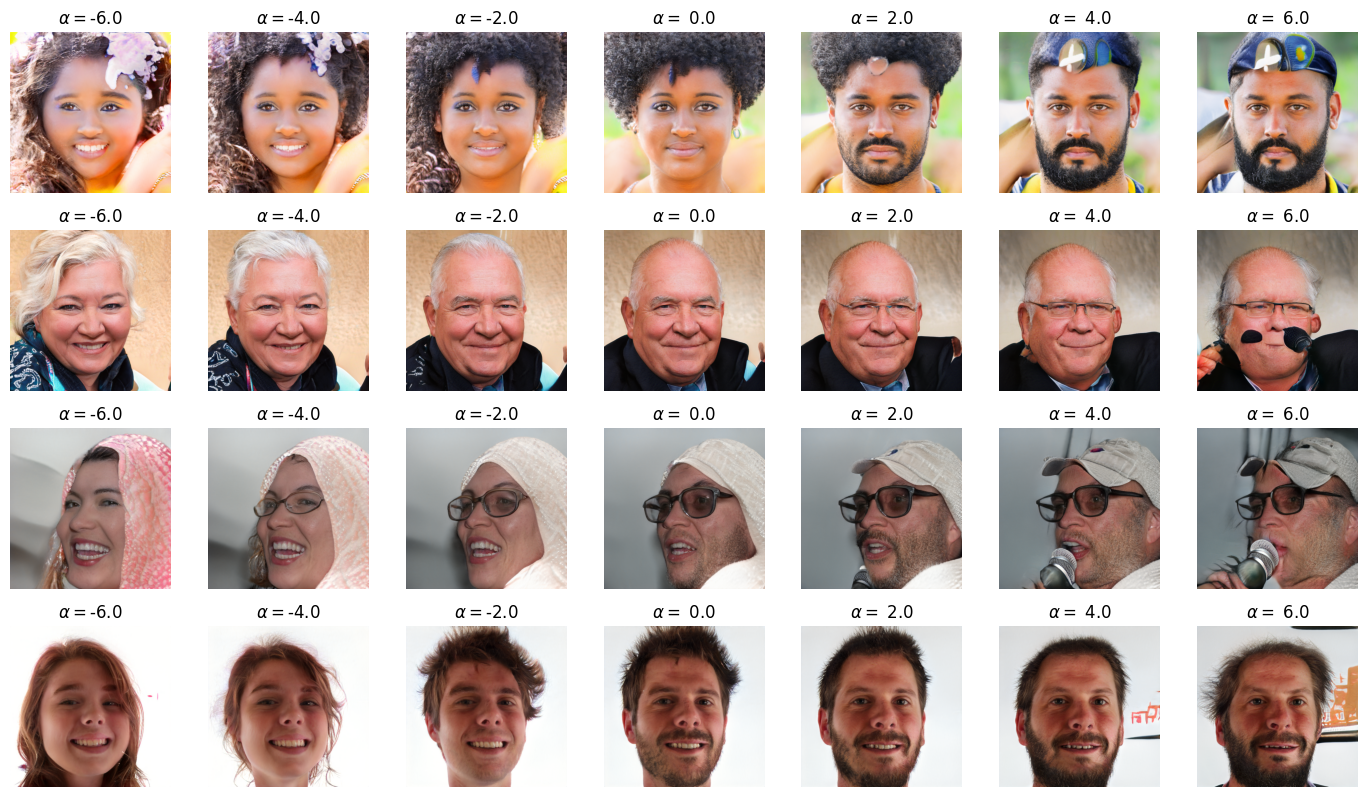

In [13]:
if not LOAD_BOUNDARIES:
    sample_directions([n_male])

## Compute eyeglass boundary

In [ ]:
if not LOAD_BOUNDARIES:
    worst_eyeglass_scores, best_eyeglass_scores = get_classes(eyeglasses_scores, "eyeglasses_score")

In [ ]:
if not LOAD_BOUNDARIES:
    N_SELECTED = 64

    _ = plt.figure(figsize=(N_SELECTED, N_SELECTED))
    for i in range(N_SELECTED):
        ax = plt.subplot(16, N_SELECTED//4, i+1)
        img = worst_eyeglass_scores[i].image
        img = img.permute(1, 2, 0)
        img = img.cpu().numpy()
        ax.imshow(img)
        ax.set_axis_off()
    plt.tight_layout()
    _ = plt.show()

    _ = plt.figure(figsize=(N_SELECTED, N_SELECTED))
    for i in range(N_SELECTED):
        ax = plt.subplot(16, N_SELECTED//4, N_SELECTED+i+1)
        img = best_eyeglass_scores[i].image
        img = img.permute(1, 2, 0)
        img = img.cpu().numpy()
        ax.imshow(img)
        ax.set_axis_off()

    plt.tight_layout()
    _ = plt.show()

In [ ]:
if not LOAD_BOUNDARIES:
    X = torch.stack([img.latent_w[0] for img in worst_eyeglass_scores] + [img.latent_w[0] for img in best_eyeglass_scores])
    y = torch.Tensor([0] * len(worst_eyeglass_scores) + [1] * len(best_eyeglass_scores))

    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )

    svm_classifier_eyeglass = sklearn.svm.SVC(kernel='linear', C=1.0, random_state=SEED)
    svm_classifier_eyeglass.fit(X_train, y_train)

    y_pred = svm_classifier_eyeglass.predict(X_test)
    print(f"Accuracy: {sklearn.metrics.accuracy_score(y_test, y_pred):.2f}")

In [ ]:
if not LOAD_BOUNDARIES:
    n1 = svm_classifier_eyeglass.coef_[0] / np.linalg.norm(svm_classifier_eyeglass.coef_[0])
    n1 = np.stack([n1]*G.num_ws).reshape(1, G.num_ws, G.w_dim)
    n1 = torch.Tensor(n1).to(device)

    b1 = torch.tensor(svm_classifier_eyeglass.intercept_, dtype=torch.float32)

    torch.save(Boundary(n1, b1), MODELS_DIR / "eyeglass_boundary.npz")

In [ ]:
sample_directions([n1])

## Compute age boundary

In [ ]:
if not LOAD_BOUNDARIES:
    worst_young_scores, best_young_scores = get_classes(young_scores, "young_score", low_bound=0)

In [ ]:
if not LOAD_BOUNDARIES:
    N_SELECTED = 64

    _ = plt.figure(figsize=(N_SELECTED, N_SELECTED))
    for i in range(N_SELECTED):
        ax = plt.subplot(16, N_SELECTED//4, i+1)
        img = worst_young_scores[i].image
        img = img.permute(1, 2, 0)
        img = img.cpu().numpy()
        ax.imshow(img)
        ax.set_axis_off()
    plt.tight_layout()
    _ = plt.show()

    _ = plt.figure(figsize=(N_SELECTED, N_SELECTED))
    for i in range(N_SELECTED):
        ax = plt.subplot(16, N_SELECTED//4, N_SELECTED+i+1)
        img = best_young_scores[i].image
        img = img.permute(1, 2, 0)
        img = img.cpu().numpy()
        ax.imshow(img)
        ax.set_axis_off()

    plt.tight_layout()
    _ = plt.show()

In [ ]:
if not LOAD_BOUNDARIES:
    X = torch.stack([img.latent_w[0] for img in worst_young_scores] + [img.latent_w[0] for img in best_young_scores])
    y = torch.Tensor([0] * len(worst_young_scores) + [1] * len(best_young_scores))

    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )

    svm_classifier_young = sklearn.svm.SVC(kernel='linear', C=1.0, random_state=SEED)
    svm_classifier_young.fit(X_train, y_train)

    y_pred = svm_classifier_young.predict(X_test)
    print(f"Accuracy: {sklearn.metrics.accuracy_score(y_test, y_pred):.2f}")

In [ ]:
if not LOAD_BOUNDARIES:
    n2 = svm_classifier_young.coef_[0] / np.linalg.norm(svm_classifier_young.coef_[0])
    n2 = np.stack([n2]*G.num_ws).reshape(1, G.num_ws, G.w_dim)
    n2 = torch.Tensor(n2).to(device)
    n2 *= -1    # we need to change the direction so positive is older

    b2 = torch.tensor(svm_classifier_young.intercept_, dtype=torch.float32)

    torch.save(Boundary(n2, b2), MODELS_DIR / "young_boundary.npz")

In [ ]:
sample_directions([n2])

## Compute eyeglass w/ cond. on age boundary

In [ ]:
if not LOAD_BOUNDARIES:
    n = n1 - torch.inner(n1[0,0], n2[0,0]) * n2
    n = n / torch.norm(n[0, 0])

In [ ]:
print(torch.inner(n1[0, 0], n2[0, 0]).item())
print(torch.inner(n[0, 0], n2[0, 0]).item())

In [ ]:
sample_directions([n1, n])